In [1]:
# If you are using colab, you can mount your google drive and access data from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### SUPER MERGER PRE-TRAINING
Fusione dei 5 dataset elaborati finora a 1000 punti.

   AVVIO FUSIONE DATASET PER PRE-TRAINING (1000 pt)   
1. Caricamento TROPHY...
   -> 115913 spettri aggiunti.


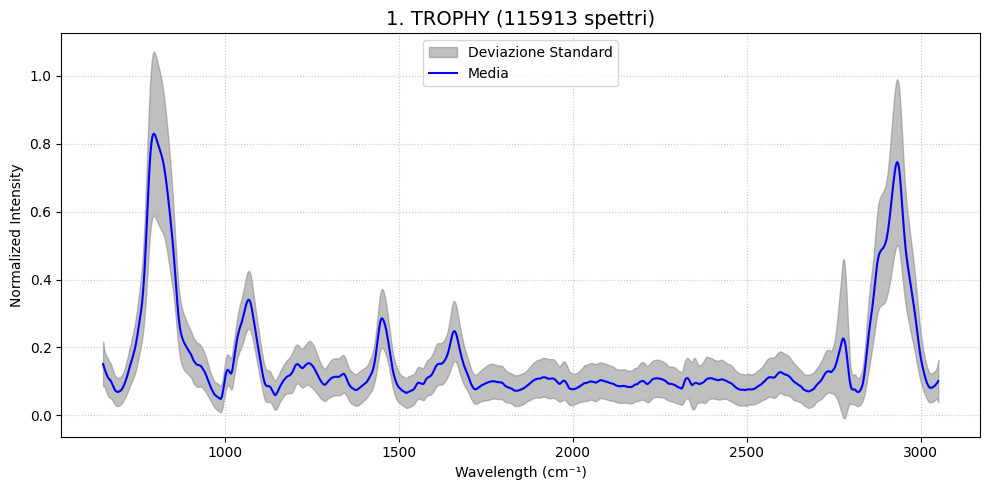

ATTENZIONE: File DeepR_Inputs_FingerPrint.npz non trovato in /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/. Salto...
3. Caricamento CELLS...
   -> 15429 spettri aggiunti.


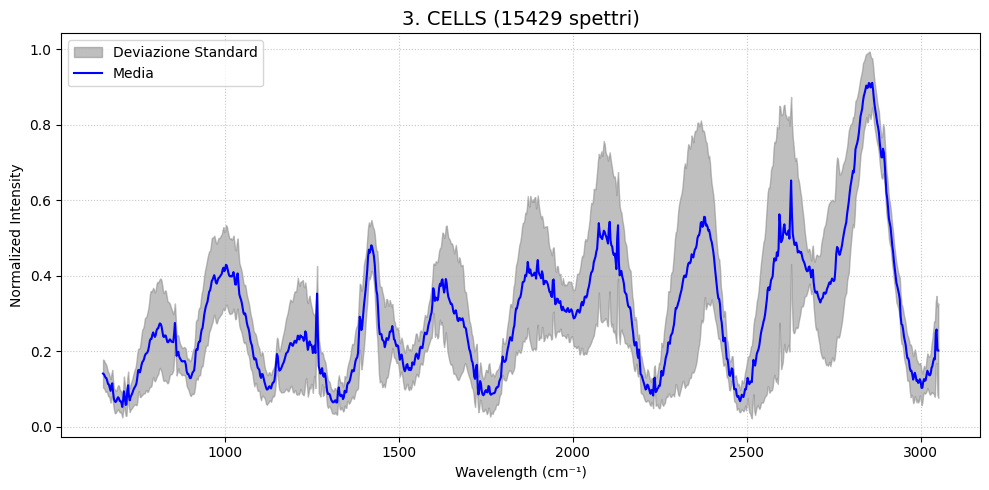

4. Caricamento TWIST...
   -> 16496 spettri aggiunti.


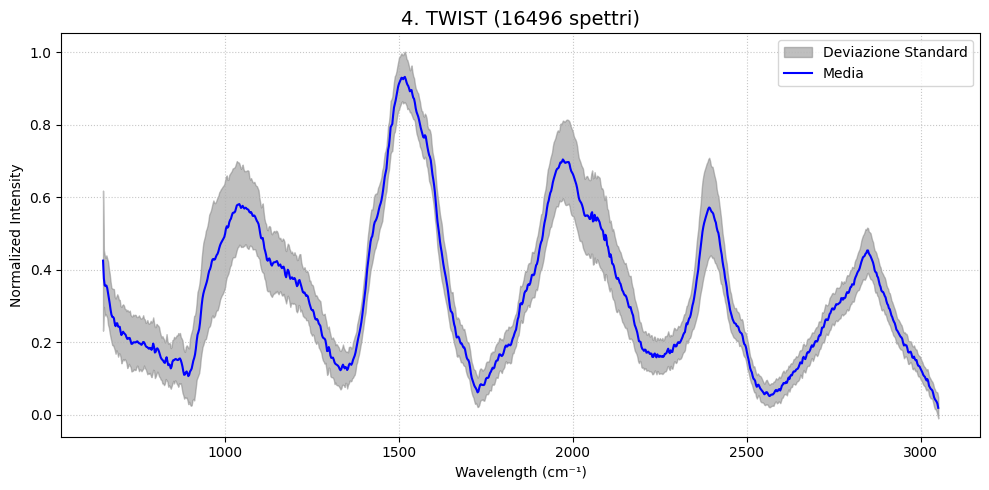

5. Caricamento IMMUNO...
   -> 11099 spettri aggiunti.


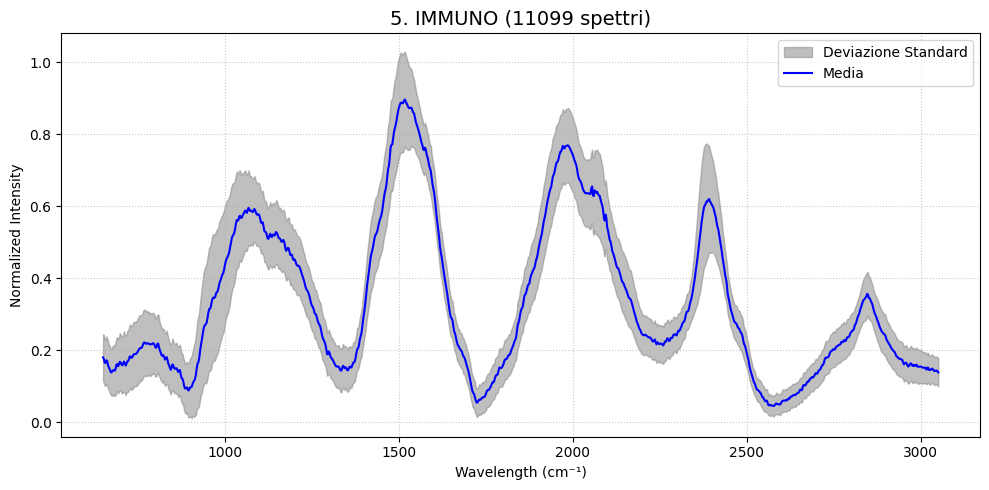

CONTEGGIO FINALE: 158937 spettri raccolti.
Unione matrici in corso...


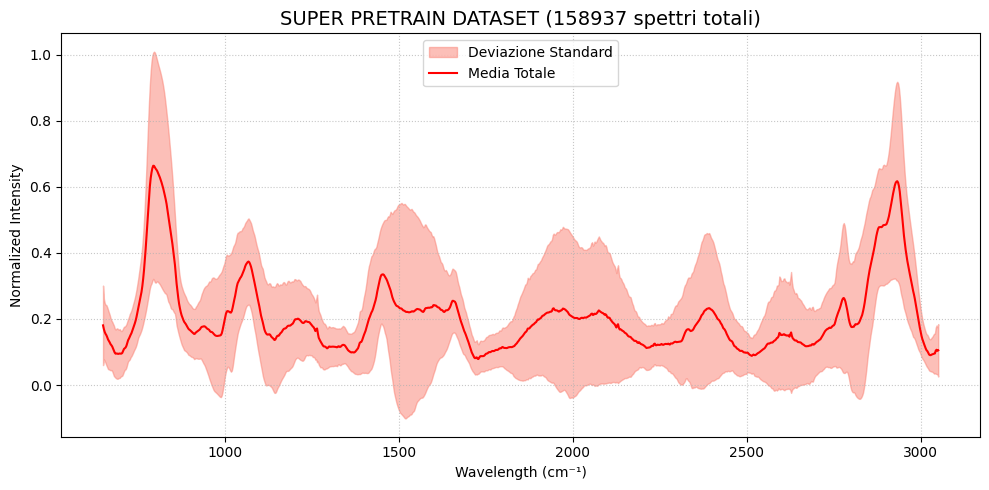

Dimensioni matrice finale:
(158937, 1000)
Salvataggio in /content/drive/MyDrive/Tesi_Raman/Datasets/PreTraining_Ready/1000_pt/FingerPrint/Min-Max/SUPER_PRETRAIN_1000pt.npz...
   DATASET PRONTO PER PYTHON! BUON PRE-TRAINING!      


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- Configurazione Percorsi ---
in_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/'
out_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/PreTraining_Ready/1000_pt/FingerPrint/Min-Max'
os.makedirs(out_dir, exist_ok=True)

# Lista dei dataset elaborati finora (verifica che i nomi dei file corrispondano ai tuoi salvataggi reali)
datasets_to_merge = [
    ('TROPHY', 'trophy_normalized_spectra_FingerPrint.npz'),             # Dataset 1
    ('DEEPR', 'DeepR_Inputs_FingerPrint.npz'),               # Dataset 2 (oppure 'DeepR_Combined_1000pt.npz')
    ('CELLS', 'CELLS_1000pt_FingerPrint.npz'),               # Dataset 3
    ('TWIST', 'TWIST_1000pt_FingerPrint.npz'),               # Dataset 3A
    ('IMMUNO', 'IMMUNO_1000pt_FingerPrint.npz')              # Dataset 3B
]

totale_spettri = 0
X_list = []
Y_list = []
asse_target = None

print("======================================================")
print("   AVVIO FUSIONE DATASET PER PRE-TRAINING (1000 pt)   ")
print("======================================================")

for idx, (nome_ds, filename) in enumerate(datasets_to_merge, start=1):
    filepath = os.path.join(in_dir, filename)
    if not os.path.exists(filepath):
        print(f"ATTENZIONE: File {filename} non trovato in {in_dir}. Salto...")
        continue

    print(f"{idx}. Caricamento {nome_ds}...")
    data = np.load(filepath)
    X_curr = data['spectra']

    # Recuperiamo l'asse X (interpolato a 1000pt) dal primo dataset trovato
    if asse_target is None:
        asse_target = data['wavelengths']

    n_curr = X_curr.shape[0]
    print(f"   -> {n_curr} spettri aggiunti.")

    X_list.append(X_curr)
    Y_list.append(np.ones(n_curr, dtype=int) * idx) # Etichetta di provenienza (1-5)
    totale_spettri += n_curr

    # --- Grafico ---
    fig = plt.figure(figsize=(10, 5))
    mu = np.mean(X_curr, axis=0)
    sigma = np.std(X_curr, axis=0)

    plt.fill_between(asse_target, mu+sigma, mu-sigma, color='gray', alpha=0.5, label='Deviazione Standard')
    plt.plot(asse_target, mu, 'b', linewidth=1.5, label='Media')
    plt.title(f"{idx}. {nome_ds} ({n_curr} spettri)", fontsize=14)
    plt.xlabel("Wavelength (cm⁻¹)")
    plt.ylabel("Normalized Intensity")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='best')
    plt.tight_layout()

    # Salvataggio Plot
    saveas_path = os.path.join(out_dir, f"Plot_{idx}_{nome_ds}.png")
    plt.savefig(saveas_path)
    plt.show()

print("======================================================")
print(f"CONTEGGIO FINALE: {totale_spettri} spettri raccolti.")
print("Unione matrici in corso...")

if len(X_list) > 0:
    # Uniamo tutto in un'unica matrice
    X_SUPER_PRETRAIN = np.vstack(X_list)
    dataset_source = np.concatenate(Y_list) # Vettore con le etichette di provenienza

    # Liberiamo la RAM (equivalente al 'clear' di MATLAB)
    del X_list, Y_list

    # --- Grafico SUPER DATASET ---
    fig_super = plt.figure(figsize=(10, 5))
    mu_tot = np.mean(X_SUPER_PRETRAIN, axis=0)
    sigma_tot = np.std(X_SUPER_PRETRAIN, axis=0)

    plt.fill_between(asse_target, mu_tot+sigma_tot, mu_tot-sigma_tot, color='salmon', alpha=0.5, label='Deviazione Standard')
    plt.plot(asse_target, mu_tot, 'r', linewidth=1.5, label='Media Totale')
    plt.title(f"SUPER PRETRAIN DATASET ({totale_spettri} spettri totali)", fontsize=14)
    plt.xlabel("Wavelength (cm⁻¹)")
    plt.ylabel("Normalized Intensity")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'Plot_SUPER_PRETRAIN.png'))
    plt.show()

    print("Dimensioni matrice finale:")
    print(X_SUPER_PRETRAIN.shape)

    # Salvataggio Finale
    save_mat_path = os.path.join(out_dir, 'SUPER_PRETRAIN_1000pt.npz')
    print(f"Salvataggio in {save_mat_path}...")
    np.savez(save_mat_path,
             X_SUPER_PRETRAIN=X_SUPER_PRETRAIN,
             asse_target=asse_target,
             dataset_source=dataset_source)

    print("======================================================")
    print("   DATASET PRONTO PER PYTHON! BUON PRE-TRAINING!      ")
    print("======================================================")
else:
    print("ERRORE: Nessun dataset trovato da unire.")
